### Importing Libraries

In [ ]:
import pandas as pd
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import time
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers
import PIL


In [5]:
metadata_root_path = 'data/metadata'
img_root_path = 'data/prepocessed_v2'

In [6]:
# Update paths as needed
train_df = pd.read_csv(os.path.join(metadata_root_path, 'train_metadata.csv'))
val_df = pd.read_csv(os.path.join(metadata_root_path, 'val_metadata.csv'))
test_df = pd.read_csv(os.path.join(metadata_root_path, 'test_metadata.csv'))

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Train samples: 72017
Validation samples: 8964
Test samples: 8983


In [7]:
classes = sorted(train_df['label'].unique())
num_classes = len(classes)
print("Detected classes:", classes)
class2idx = {v: i for i, v in enumerate(classes)}
train_df['label'] = train_df['label'].map(class2idx)
val_df['label'] = val_df['label'].map(class2idx)
test_df['label'] = test_df['label'].map(class2idx)

Detected classes: ['drink', 'food', 'inside', 'menu', 'outside']


In [8]:
train_df['absolute_path'] = train_df['path'].apply(lambda x: os.path.join(img_root_path, x))
val_df['absolute_path'] = val_df['path'].apply(lambda x: os.path.join(img_root_path, x))
test_df['absolute_path'] = test_df['path'].apply(lambda x: os.path.join(img_root_path, x))

Creating dataset

In [9]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

def parse_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

def get_dataset(df, shuffle=True):
    filepaths = df['absolute_path'].values
    labels = df['label'].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
train_ds = get_dataset(train_df, shuffle=True)
val_ds = get_dataset(val_df, shuffle=False)
test_ds = get_dataset(test_df, shuffle=False)

### VGG with all layers

In [11]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,381 (64.14 MB)

 Trainable params: 16,813,381 (64.14 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, 
    callbacks=[early_stop]
)
end_time = time.time()


Epoch 1/10


2251/2251 ━━━━━━━━━━━━━━━━━━━━ 11451s 5s/step - accuracy: 0.8114 - loss: 0.5141 - val_accuracy: 0.8802 - val_loss: 0.3300
Epoch 2/10
2251/2251 ━━━━━━━━━━━━━━━━━━━━ 13018s 6s/step - accuracy: 0.9090 - loss: 0.2636 - val_accuracy: 0.9240 - val_loss: 0.2130
Epoch 3/10
2251/2251 ━━━━━━━━━━━━━━━━━━━━ 12128s 5s/step - accuracy: 0.9284 - loss: 0.1986 - val_accuracy: 0.9167 - val_loss: 0.2276
Epoch 4/10
2251/2251 ━━━━━━━━━━━━━━━━━━━━ 11531s 5s/step - accuracy: 0.9454 - loss: 0.1544 - val_accuracy: 0.9225 - val_loss: 0.2539


### Training time

In [13]:
training_time = end_time - start_time
min, sec = divmod(training_time, 60)
hr, min = divmod(min, 60)
print(f"Training Time: {hr:.0f} hour {min:.0f} min {sec:.2f} sec")

Training Time: 13 hour 22 min 8.12 sec


### Accuracy

In [14]:
results = model.evaluate(test_ds)
print("Test Loss, Test Accuracy:", results)

281/281 ━━━━━━━━━━━━━━━━━━━━ 414s 1s/step - accuracy: 0.9192 - loss: 0.2178
Test Loss, Test Accuracy: [0.2181328386068344, 0.9216297268867493]


In [15]:
# Save as .keras (recommended)
model.save("vgg_all_layers.keras")

# Save as .h5 (optional for compatibility)
model.save("vgg_all_layers.h5")

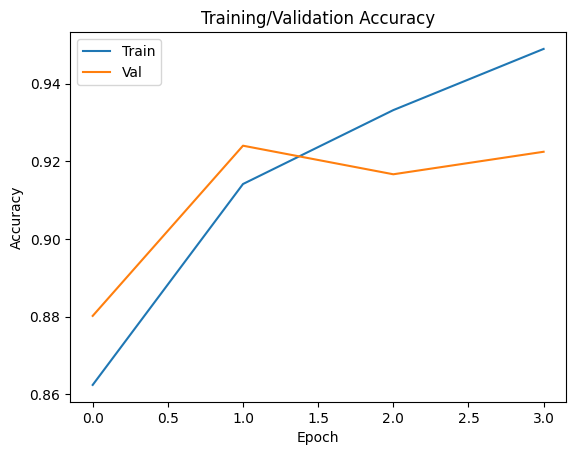

In [16]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training/Validation Accuracy')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

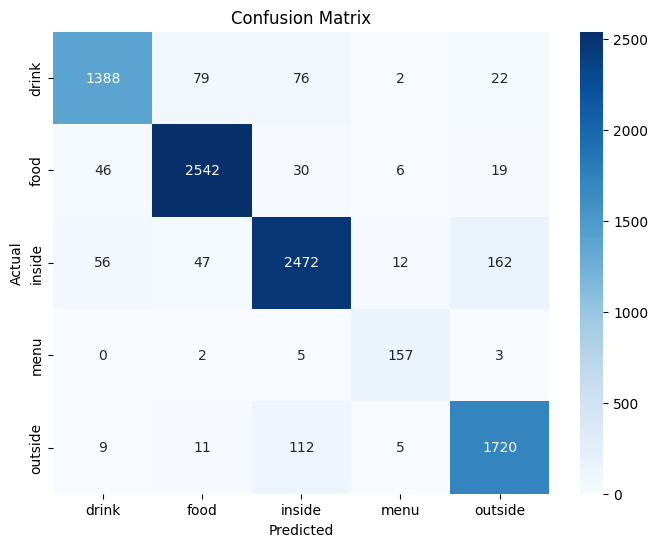

Multiclass AUC (OvR): 0.992


In [17]:
# Get predictions
y_true = []
y_pred = []
y_proba = []

for images, labels in test_ds:
    probs = model.predict(images)
    preds = np.argmax(probs, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_proba.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# AUC (One-vs-Rest)
try:
    auc = roc_auc_score(tf.keras.utils.to_categorical(y_true, num_classes),
                        y_proba, multi_class='ovr')
    print(f'Multiclass AUC (OvR): {auc:.3f}')
except Exception as e:
    print("AUC calculation error:", e)


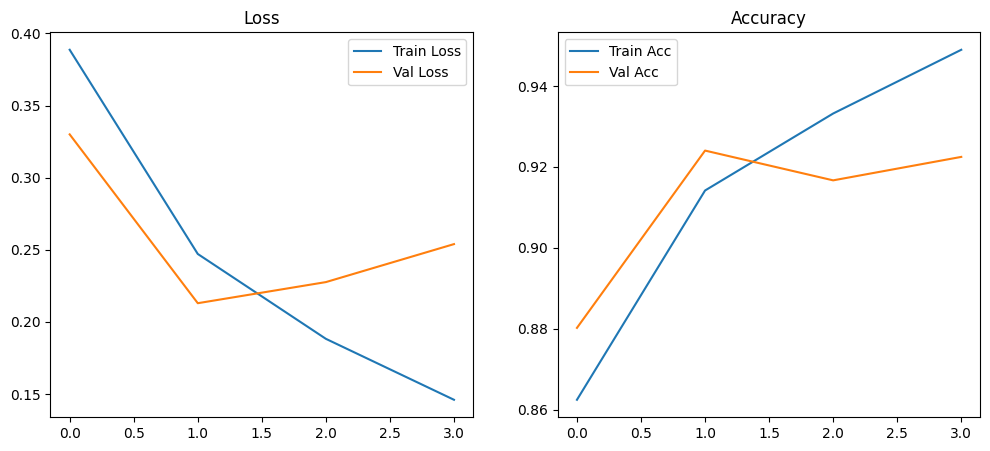

In [18]:
# Training and Validation Loss/Accuracy Plots
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()


### Model Tuning 1

In [19]:
# Data augmentation (put before the base model)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

inputs = tf.keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = base_model(x, training=True)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,381 (64.14 MB)

 Trainable params: 16,813,381 (64.14 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
tuned_start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)
tuned_end_time = time.time()

Epoch 1/10
2251/2251 ━━━━━━━━━━━━━━━━━━━━ 11538s 5s/step - accuracy: 0.8712 - loss: 0.3659 - val_accuracy: 0.9101 - val_loss: 0.2525
Epoch 2/10
2251/2251 ━━━━━━━━━━━━━━━━━━━━ 12200s 5s/step - accuracy: 0.9071 - loss: 0.2653 - val_accuracy: 0.8803 - val_loss: 0.3446
Epoch 3/10
2251/2251 ━━━━━━━━━━━━━━━━━━━━ 12180s 5s/step - accuracy: 0.9171 - loss: 0.2368 - val_accuracy: 0.8872 - val_loss: 0.3215


### Training time

In [21]:
tuned_training_time = tuned_end_time - tuned_start_time
min, sec = divmod(tuned_training_time, 60)
hr, min = divmod(min, 60)
print(f"Training Time: {hr:.0f} hour {min:.0f} min {sec:.2f} sec")

Training Time: 9 hour 58 min 38.12 sec


### Model Tuning 2

In [22]:
# Change batch size and optimizer learning rate
BATCH_SIZE = 64  # Try a larger batch size if you have GPU memory

train_ds = get_dataset(train_df, shuffle=True)  # Use new batch size in get_dataset()

# Compile with a lower learning rate if model is unstable
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),  # Lower LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [23]:
tuned_start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)
tuned_end_time = time.time()


Epoch 1/10
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 12212s 11s/step - accuracy: 0.9242 - loss: 0.2081 - val_accuracy: 0.9206 - val_loss: 0.2245
Epoch 2/10
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 12296s 11s/step - accuracy: 0.9370 - loss: 0.1744 - val_accuracy: 0.9189 - val_loss: 0.2355
Epoch 3/10
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 12365s 11s/step - accuracy: 0.9444 - loss: 0.1557 - val_accuracy: 0.9127 - val_loss: 0.2563


### Training time

In [24]:
tuned_training_time = tuned_end_time - tuned_start_time
min, sec = divmod(tuned_training_time, 60)
hr, min = divmod(min, 60)
print(f"Training Time: {hr:.0f} hour {min:.0f} min {sec:.2f} sec")

Training Time: 10 hour 14 min 33.34 sec


### Accuracy

In [77]:
results = model.evaluate(test_ds)
print("Test Loss, Test Accuracy:", results)

281/281 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - accuracy: 0.9197 - loss: 0.2318
Test Loss, Test Accuracy: [0.221074640750885, 0.9207391738891602]


In [76]:
# Save as .keras (recommended)
model.save("vgg_all_layers_tuned.keras")

# Save as .h5 (optional for compatibility)
model.save("vgg_all_layers_tuned.h5")

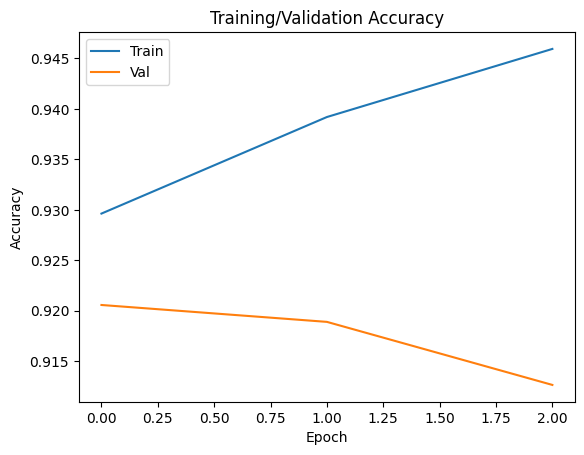

In [78]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training/Validation Accuracy')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

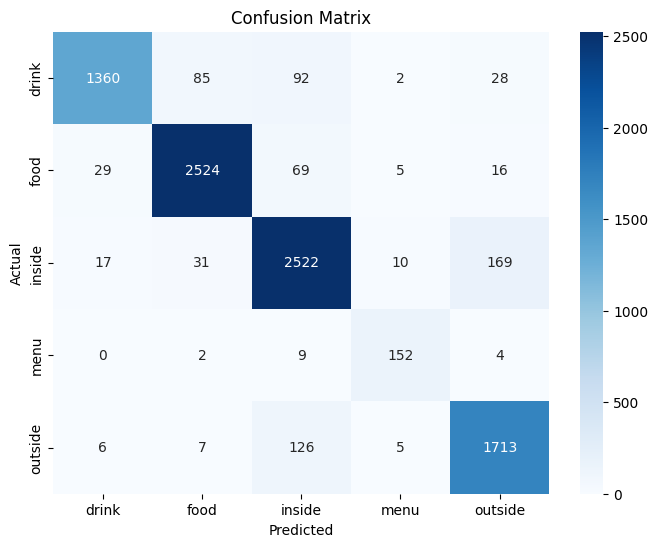

Multiclass AUC (OvR): 0.993


In [79]:
# Get predictions
y_true = []
y_pred = []
y_proba = []

for images, labels in test_ds:
    probs = model.predict(images)
    preds = np.argmax(probs, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_proba.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# AUC (One-vs-Rest)
try:
    auc = roc_auc_score(tf.keras.utils.to_categorical(y_true, num_classes),
                        y_proba, multi_class='ovr')
    print(f'Multiclass AUC (OvR): {auc:.3f}')
except Exception as e:
    print("AUC calculation error:", e)


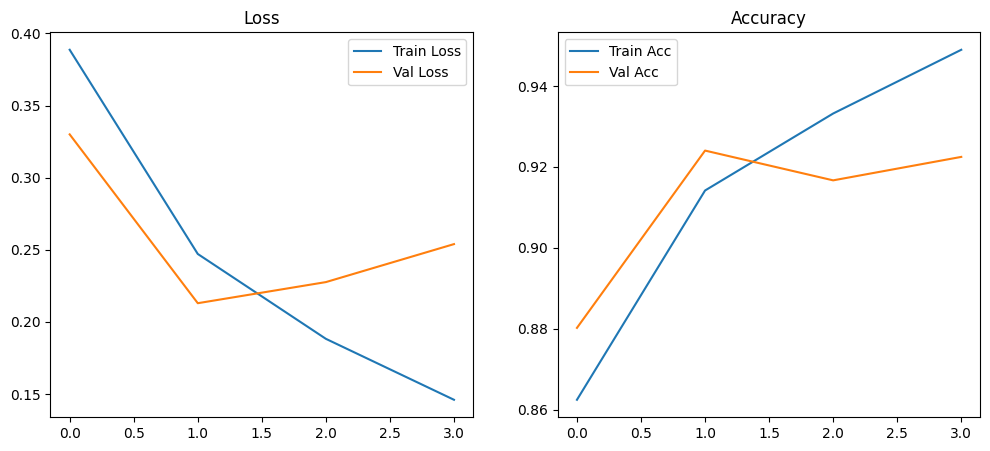

In [ ]:
# Training and Validation Loss/Accuracy Plots
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()


### Interpretation using GradCAM

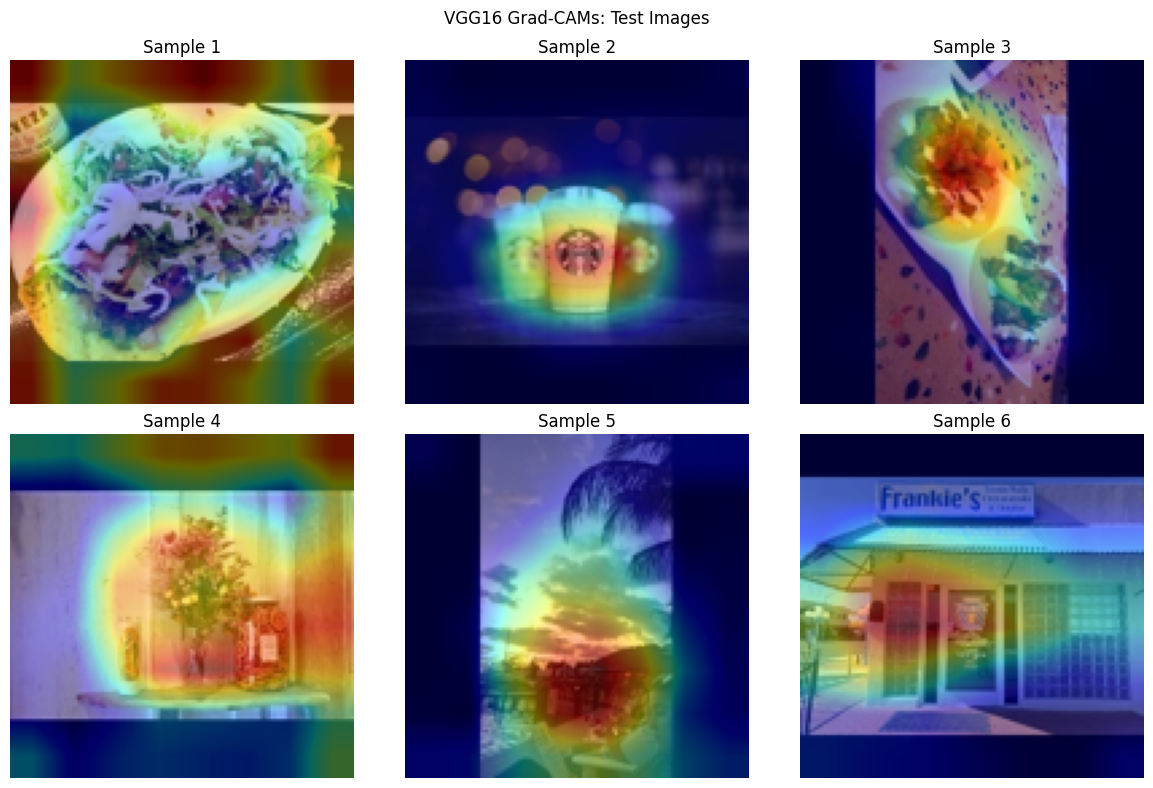

In [ ]:
def show_gradcam_overlay_purematplotlib(img_path, heatmap, alpha=0.4, ax=None):
    img = PIL.Image.open(img_path).resize((128, 128))
    img = np.array(img)
    # Resize heatmap to image size
    heatmap_resized = np.array(PIL.Image.fromarray(np.uint8(255 * heatmap)).resize((128, 128), PIL.Image.BILINEAR))
    heatmap_resized = heatmap_resized.astype(float) / 255
    if ax is None:
        plt.imshow(img)
        plt.imshow(heatmap_resized, cmap='jet', alpha=alpha)
        plt.axis('off')
    else:
        ax.imshow(img)
        ax.imshow(heatmap_resized, cmap='jet', alpha=alpha)
        ax.axis('off')

def vgg16_gradcam(img_tensor, vgg_model, last_conv_layer_name='block5_conv3'):
    grad_model = tf.keras.models.Model(
        [vgg_model.input],
        [vgg_model.get_layer(last_conv_layer_name).output, vgg_model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        tape.watch(conv_outputs)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    if grads is None:
        raise ValueError("Gradients are None! (VGG-only fallback)")
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ----- Loop over multiple images -----

num_to_show = 6  # how many test images to visualize
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for idx, ax in enumerate(axes.flat):
    if idx >= len(test_df) or idx >= num_to_show:
        break
    img_path = test_df['absolute_path'].iloc[idx]
    # Preprocess
    img = PIL.Image.open(img_path).resize((128, 128))
    img_arr = np.array(img).astype('float32') / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)
    # Grad-CAM
    heatmap = vgg16_gradcam(tf.convert_to_tensor(img_arr, dtype=tf.float32), vgg_with_head)
    show_gradcam_overlay_purematplotlib(img_path, heatmap, ax=ax)
    ax.set_title(f"Sample {idx+1}")

plt.suptitle("VGG16 Grad-CAMs: Test Images")
plt.tight_layout()
plt.show()
